# 🖼️ CIFAR-10 Image Classification using PyTorch
**By Subhadevi Krishnaraj**

CIFAR-10 has 60,000 images across 10 classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck.

In [1]:
# Step 1: Import Libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

print('PyTorch version:', torch.__version__)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

PyTorch version: 2.11.0+cu128
Using device: cuda


In [2]:
# Step 2: Load CIFAR-10 Dataset (Auto Downloads - No setup needed!)
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),       # Data augmentation
    transforms.RandomCrop(32, padding=4),    # Data augmentation
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                         download=True, transform=transform)
testset  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                         download=True, transform=test_transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader  = torch.utils.data.DataLoader(testset,  batch_size=64, shuffle=False)

classes = ('airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck')
print(f'Train samples: {len(trainset)} | Test samples: {len(testset)}')

100%|██████████| 170M/170M [00:10<00:00, 16.7MB/s]


Train samples: 50000 | Test samples: 10000


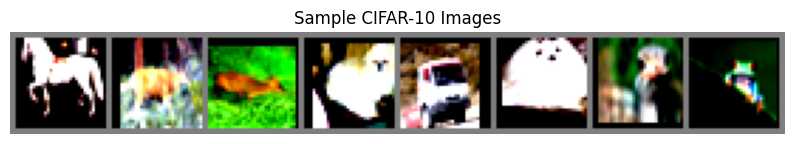

Labels: horse | deer | deer | dog | truck | dog | bird | frog


In [3]:
# Step 3: Visualize Sample Images
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.figure(figsize=(10,3))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.title('Sample CIFAR-10 Images')
    plt.show()

dataiter = iter(trainloader)
images, labels = next(dataiter)
imshow(torchvision.utils.make_grid(images[:8]))
print('Labels:', ' | '.join(classes[labels[j]] for j in range(8)))

In [4]:
# Step 4: Define CNN Model
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 16x16
            nn.Dropout(0.25),
            # Block 2
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 8x8
            nn.Dropout(0.25),
            # Block 3
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 4x4
            nn.Dropout(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

model = CNN().to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')

CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.25, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Dropout(p=0.25, inplace=Fal

In [5]:
# Step 5: Loss Function & Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
print('Criterion: CrossEntropyLoss')
print('Optimizer: Adam (lr=0.001)')
print('Scheduler: StepLR (step=10, gamma=0.5)')

Criterion: CrossEntropyLoss
Optimizer: Adam (lr=0.001)
Scheduler: StepLR (step=10, gamma=0.5)


In [6]:
# Step 6: Train the Model
EPOCHS = 20
train_losses, train_accs = [], []

for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    scheduler.step()
    epoch_loss = running_loss / len(trainloader)
    epoch_acc  = 100. * correct / total
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)
    print(f'Epoch [{epoch+1:02d}/{EPOCHS}] Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%')

Epoch [01/20] Loss: 1.6059 | Accuracy: 40.60%
Epoch [02/20] Loss: 1.2638 | Accuracy: 54.23%
Epoch [03/20] Loss: 1.1234 | Accuracy: 60.05%
Epoch [04/20] Loss: 1.0248 | Accuracy: 63.73%
Epoch [05/20] Loss: 0.9557 | Accuracy: 66.63%
Epoch [06/20] Loss: 0.8997 | Accuracy: 68.69%
Epoch [07/20] Loss: 0.8582 | Accuracy: 70.39%
Epoch [08/20] Loss: 0.8190 | Accuracy: 71.77%
Epoch [09/20] Loss: 0.7878 | Accuracy: 73.27%
Epoch [10/20] Loss: 0.7567 | Accuracy: 74.25%
Epoch [11/20] Loss: 0.6924 | Accuracy: 76.56%
Epoch [12/20] Loss: 0.6644 | Accuracy: 77.43%
Epoch [13/20] Loss: 0.6512 | Accuracy: 77.89%
Epoch [14/20] Loss: 0.6378 | Accuracy: 78.45%
Epoch [15/20] Loss: 0.6193 | Accuracy: 78.85%
Epoch [16/20] Loss: 0.6041 | Accuracy: 79.49%
Epoch [17/20] Loss: 0.5934 | Accuracy: 79.74%
Epoch [18/20] Loss: 0.5892 | Accuracy: 79.65%
Epoch [19/20] Loss: 0.5816 | Accuracy: 80.01%
Epoch [20/20] Loss: 0.5689 | Accuracy: 80.45%


In [7]:
# Step 7: Evaluate on Test Set
model.eval()
correct, total = 0, 0

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

test_acc = 100. * correct / total
print(f'\n✅ Test Accuracy: {test_acc:.2f}%')


✅ Test Accuracy: 82.58%


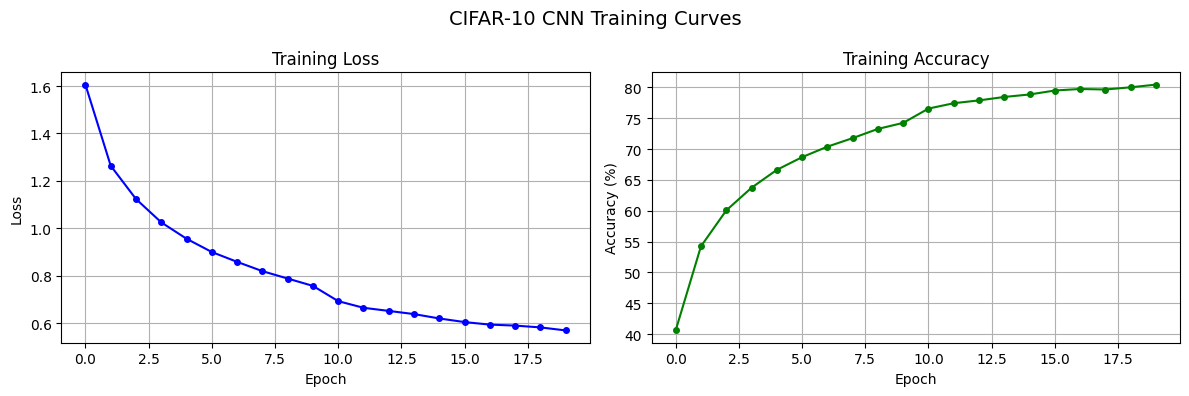

Plot saved as training_curves.png


In [8]:
# Step 8: Plot Training Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, 'b-o', markersize=4)
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True)

ax2.plot(train_accs, 'g-o', markersize=4)
ax2.set_title('Training Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.grid(True)

plt.suptitle('CIFAR-10 CNN Training Curves', fontsize=14)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as training_curves.png')

In [9]:
# Step 9: Per-Class Accuracy
class_correct = [0] * 10
class_total   = [0] * 10

model.eval()
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        for i in range(len(labels)):
            label = labels[i].item()
            class_correct[label] += (predicted[i] == labels[i]).item()
            class_total[label]   += 1

print('\n📊 Per-Class Accuracy:')
print('-' * 30)
for i in range(10):
    acc = 100 * class_correct[i] / class_total[i]
    print(f'{classes[i]:12s}: {acc:.2f}%')


📊 Per-Class Accuracy:
------------------------------
airplane    : 80.00%
automobile  : 90.60%
bird        : 66.80%
cat         : 54.00%
deer        : 83.70%
dog         : 80.10%
frog        : 94.90%
horse       : 86.90%
ship        : 96.20%
truck       : 92.60%


In [10]:
# Step 10: Save the Model
torch.save(model.state_dict(), 'cifar10_cnn.pth')
print('✅ Model saved as cifar10_cnn.pth')
print(f'\n🎯 Final Test Accuracy: {test_acc:.2f}%')
print('You can now upload this notebook + cifar10_cnn.pth to GitHub!')

✅ Model saved as cifar10_cnn.pth

🎯 Final Test Accuracy: 82.58%
You can now upload this notebook + cifar10_cnn.pth to GitHub!
